In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_ROOT = "/content/drive/MyDrive/reddit_data/raw_yearly"

In [ ]:
import os
import re
import json
from datetime import datetime
from collections import defaultdict
import pandas as pd

In [ ]:
# Picking one subreddit folder to test first
SUBREDDIT = "MachineLearning"
subreddit_dir = os.path.join(DATA_ROOT, SUBREDDIT)

print("Folder exists:", os.path.exists(subreddit_dir))
print("Sample files:", os.listdir(subreddit_dir)[:5])

Folder exists: True
Sample files: ['r_MachineLearning_comments_2009.jsonl', 'r_MachineLearning_comments_2010.jsonl', 'r_MachineLearning_comments_2011.jsonl', 'r_MachineLearning_comments_2012.jsonl', 'r_MachineLearning_comments_2013.jsonl']


In [ ]:
token_pattern = re.compile(r"[a-zA-Z][a-zA-Z0-9_'-]*")

def stream_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        for line_num, line in enumerate(f, start=1):
            try:
                yield json.loads(line)
            except json.JSONDecodeError:
                continue

def get_month(created_utc):
    try:
        dt = datetime.utcfromtimestamp(int(created_utc))
        return dt.strftime("%Y-%m")
    except Exception:
        return None

def tokenize(text):
    if not isinstance(text, str):
        return []
    text = text.lower()
    return token_pattern.findall(text)

In [ ]:
word_counts = defaultdict(int)

files = sorted(os.listdir(subreddit_dir))[:2]   # test on first 2 files only
print("Testing files:", files)

for fname in files:
    fpath = os.path.join(subreddit_dir, fname)
    print("Processing:", fpath)

    for comment in stream_jsonl(fpath):
        body = comment.get("body", "")
        created_utc = comment.get("created_utc")

        month = get_month(created_utc)
        if month is None:
            continue

        tokens = tokenize(body)
        for token in tokens:
            word_counts[(token, month)] += 1

print("Unique word-month pairs:", len(word_counts))

Testing files: ['r_MachineLearning_comments_2009.jsonl', 'r_MachineLearning_comments_2010.jsonl']
Processing: /content/drive/MyDrive/reddit_data/raw_yearly/MachineLearning/r_MachineLearning_comments_2009.jsonl


/tmp/ipykernel_4365/938414977.py:13: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  dt = datetime.utcfromtimestamp(int(created_utc))


Processing: /content/drive/MyDrive/reddit_data/raw_yearly/MachineLearning/r_MachineLearning_comments_2010.jsonl
Unique word-month pairs: 30290


In [ ]:
rows = [
    {"word": word, "month": month, "count": count}
    for (word, month), count in word_counts.items()
]

df = pd.DataFrame(rows)
df = df.sort_values(["word", "month"]).reset_index(drop=True)

print(df.head(20))
print(df[df["word"] == "model"].tail(20))

          word    month  count
0            a  2009-07     60
1            a  2009-08     89
2            a  2009-09    138
3            a  2009-10    151
4            a  2009-11    184
5            a  2009-12     36
6            a  2010-01    189
7            a  2010-02     70
8            a  2010-03    202
9            a  2010-04    121
10           a  2010-05     78
11           a  2010-06    259
12           a  2010-07    180
13           a  2010-08    125
14           a  2010-09    183
15           a  2010-10    186
16           a  2010-11    587
17           a  2010-12    224
18          a-  2010-06      2
19  a-distance  2010-11      1
        word    month  count
16635  model  2009-07      6
16636  model  2009-08      1
16637  model  2009-09      4
16638  model  2009-10      4
16639  model  2009-11     16
16640  model  2010-01      2
16641  model  2010-03     12
16642  model  2010-04      3
16643  model  2010-05      6
16644  model  2010-06     10
16645  model  2010-07     11
1

In [ ]:
OUTPUT_DIR = "/content/drive/MyDrive/reddit_data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

out_path = os.path.join(OUTPUT_DIR, f"{SUBREDDIT}_word_counts_test.parquet")
df.to_parquet(out_path, index=False)

print("Saved to:", out_path)

Saved to: /content/drive/MyDrive/reddit_data/processed/MachineLearning_word_counts_test.parquet


In [ ]:
word_counts = defaultdict(int)

files = sorted(os.listdir(subreddit_dir))
print("Total files:", len(files))

for i, fname in enumerate(files, start=1):
    fpath = os.path.join(subreddit_dir, fname)
    print(f"[{i}/{len(files)}] Processing:", fname)

    for comment in stream_jsonl(fpath):
        body = comment.get("body", "")
        created_utc = comment.get("created_utc")

        month = get_month(created_utc)
        if month is None:
            continue

        tokens = tokenize(body)
        for token in tokens:
            word_counts[(token, month)] += 1

rows = [
    {"word": word, "month": month, "count": count}
    for (word, month), count in word_counts.items()
]

df = pd.DataFrame(rows).sort_values(["word", "month"]).reset_index(drop=True)

out_path = os.path.join(OUTPUT_DIR, f"{SUBREDDIT}_word_counts.parquet")
df.to_parquet(out_path, index=False)

print("Saved full file to:", out_path)
print("Rows:", len(df))

Total files: 18
[1/18] Processing: r_MachineLearning_comments_2009.jsonl
[2/18] Processing: r_MachineLearning_comments_2010.jsonl
[3/18] Processing: r_MachineLearning_comments_2011.jsonl


/tmp/ipykernel_4365/938414977.py:13: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  dt = datetime.utcfromtimestamp(int(created_utc))


[4/18] Processing: r_MachineLearning_comments_2012.jsonl
[5/18] Processing: r_MachineLearning_comments_2013.jsonl
[6/18] Processing: r_MachineLearning_comments_2014.jsonl
[7/18] Processing: r_MachineLearning_comments_2015.jsonl
[8/18] Processing: r_MachineLearning_comments_2016.jsonl
[9/18] Processing: r_MachineLearning_comments_2017.jsonl
[10/18] Processing: r_MachineLearning_comments_2018.jsonl
[11/18] Processing: r_MachineLearning_comments_2019.jsonl
[12/18] Processing: r_MachineLearning_comments_2020.jsonl
[13/18] Processing: r_MachineLearning_comments_2021.jsonl
[14/18] Processing: r_MachineLearning_comments_2022.jsonl
[15/18] Processing: r_MachineLearning_comments_2023.jsonl
[16/18] Processing: r_MachineLearning_comments_2024.jsonl
[17/18] Processing: r_MachineLearning_comments_2025.jsonl
[18/18] Processing: r_MachineLearning_comments_2026.jsonl
Saved full file to: /content/drive/MyDrive/reddit_data/processed/MachineLearning_word_counts.parquet
Rows: 2657194


In [ ]:
for w in ["model", "agent", "token", "prompt"]:
    print("\nWORD:", w)
    print(df[df["word"] == w].tail(12))


WORD: model
          word    month  count
1470765  model  2025-04    759
1470766  model  2025-05    905
1470767  model  2025-06   1179
1470768  model  2025-07    741
1470769  model  2025-08    642
1470770  model  2025-09    611
1470771  model  2025-10    477
1470772  model  2025-11    502
1470773  model  2025-12    584
1470774  model  2026-01    486
1470775  model  2026-02    475
1470776  model  2026-03    142

WORD: agent
        word    month  count
54123  agent  2025-04     51
54124  agent  2025-05     74
54125  agent  2025-06     94
54126  agent  2025-07     48
54127  agent  2025-08     31
54128  agent  2025-09     23
54129  agent  2025-10     52
54130  agent  2025-11     26
54131  agent  2025-12     68
54132  agent  2026-01     53
54133  agent  2026-02     77
54134  agent  2026-03     42

WORD: token
          word    month  count
2387553  token  2025-04     83
2387554  token  2025-05     74
2387555  token  2025-06    176
2387556  token  2025-07     47
2387557  token  2025-08   

build appearance + breakout detection

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
def get_word_timeline(df, word):
    out = df[df["word"] == word].copy()
    out = out.sort_values("month").reset_index(drop=True)
    return out

In [ ]:
def find_appearance_month(df, word, min_count=20, sustain_months=2):
    timeline = get_word_timeline(df, word)

    if timeline.empty:
        return None, None

    counts = timeline["count"].tolist()
    months = timeline["month"].tolist()

    for i in range(len(counts) - sustain_months + 1):
        window = counts[i:i+sustain_months]
        if all(c >= min_count for c in window):
            return months[i], timeline.iloc[i:i+sustain_months]

    return None, None

In [ ]:
def find_breakout_month(df, word, appearance_month, min_count=30, growth_ratio=3.0, lookback=3):

    timeline = get_word_timeline(df, word)

    if timeline.empty:
        return None, None

    counts = timeline["count"].tolist()
    months = timeline["month"].tolist()

    for i in range(lookback, len(counts)):

        # ignore months before appearance
        if months[i] < appearance_month:
            continue

        prev_avg = np.mean(counts[i-lookback:i])
        curr = counts[i]

        if prev_avg > 0 and curr >= min_count and (curr / prev_avg) >= growth_ratio:

            return months[i], {
                "month": months[i],
                "count": curr,
                "prev_avg": prev_avg,
                "growth_ratio": curr / prev_avg
            }

    return None, None

appearance_month, _ = find_appearance_month(df, w)

breakout_month, breakout_info = find_breakout_month(
    df,
    w,
    appearance_month
)

In [ ]:
test_words = ["model", "agent", "token", "prompt"]

for w in test_words:

    appearance_month, appearance_window = find_appearance_month(
        df, w, min_count=20, sustain_months=2
    )

    breakout_month, breakout_info = find_breakout_month(
        df,
        w,
        appearance_month,
        min_count=30,
        growth_ratio=3.0,
        lookback=3
    )

    print(f"\nWORD: {w}")
    print("Appearance:", appearance_month)
    print("Breakout:", breakout_month)
    print("Breakout info:", breakout_info)


WORD: model
Appearance: 2011-05
Breakout: 2011-11
Breakout info: {'month': '2011-11', 'count': 117, 'prev_avg': np.float64(28.0), 'growth_ratio': np.float64(4.178571428571429)}

WORD: agent
Appearance: 2015-06
Breakout: 2015-07
Breakout info: {'month': '2015-07', 'count': 49, 'prev_avg': np.float64(12.0), 'growth_ratio': np.float64(4.083333333333333)}

WORD: token
Appearance: 2018-10
Breakout: 2021-12
Breakout info: {'month': '2021-12', 'count': 64, 'prev_avg': np.float64(12.666666666666666), 'growth_ratio': np.float64(5.052631578947369)}

WORD: prompt
Appearance: 2020-07
Breakout: 2020-07
Breakout info: {'month': '2020-07', 'count': 32, 'prev_avg': np.float64(8.666666666666666), 'growth_ratio': np.float64(3.6923076923076925)}


In [ ]:
timeline_model = get_word_timeline(df, "model")
print(timeline_model.head(30))
print(timeline_model.tail(30))

     word    month  count
0   model  2009-07      6
1   model  2009-08      1
2   model  2009-09      4
3   model  2009-10      4
4   model  2009-11     16
5   model  2010-01      2
6   model  2010-03     12
7   model  2010-04      3
8   model  2010-05      6
9   model  2010-06     10
10  model  2010-07     11
11  model  2010-08      6
12  model  2010-09     17
13  model  2010-10      9
14  model  2010-11     36
15  model  2010-12      8
16  model  2011-01     14
17  model  2011-02      7
18  model  2011-03     20
19  model  2011-04      4
20  model  2011-05     26
21  model  2011-06     26
22  model  2011-07     19
23  model  2011-08     10
24  model  2011-09     28
25  model  2011-10     46
26  model  2011-11    117
27  model  2011-12     39
28  model  2012-01     33
29  model  2012-02     42
      word    month  count
169  model  2023-10   1277
170  model  2023-11   1431
171  model  2023-12   1645
172  model  2024-01   1960
173  model  2024-02   1830
174  model  2024-03   1538
175  

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_word_timeline(df, word):

    timeline = get_word_timeline(df, word)

    if timeline.empty:
        print("No data")
        return

    months = timeline["month"]
    counts = timeline["count"]

    plt.figure(figsize=(14,5))
    plt.plot(months, counts)

    # show fewer ticks
    step = max(1, len(months)//10)
    plt.xticks(months[::step], rotation=45)

    plt.title(f"Monthly counts for '{word}'")
    plt.xlabel("Month")
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

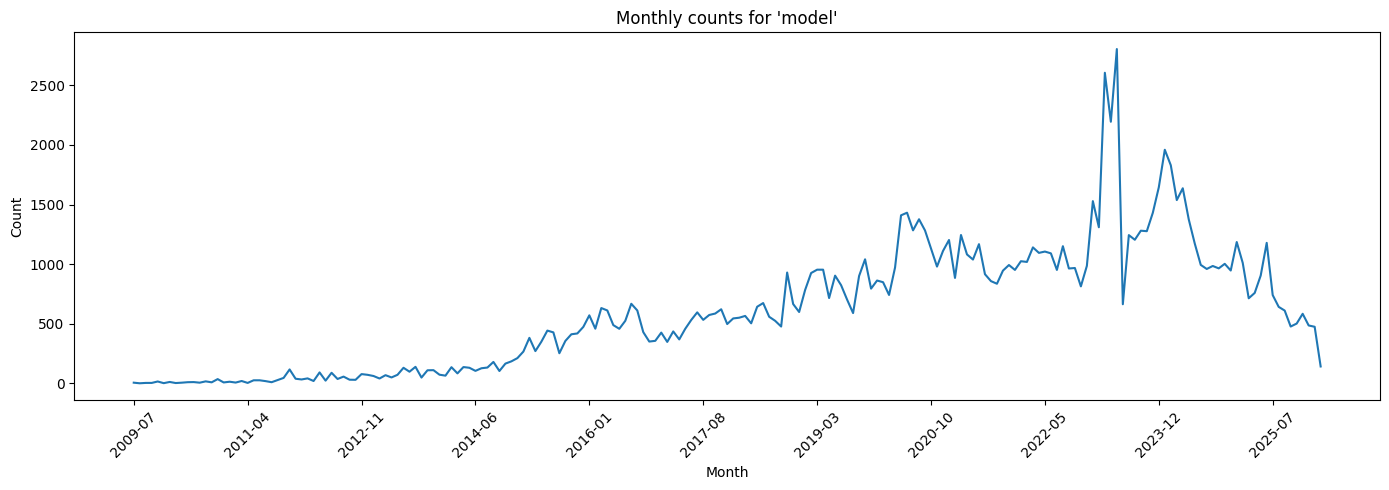

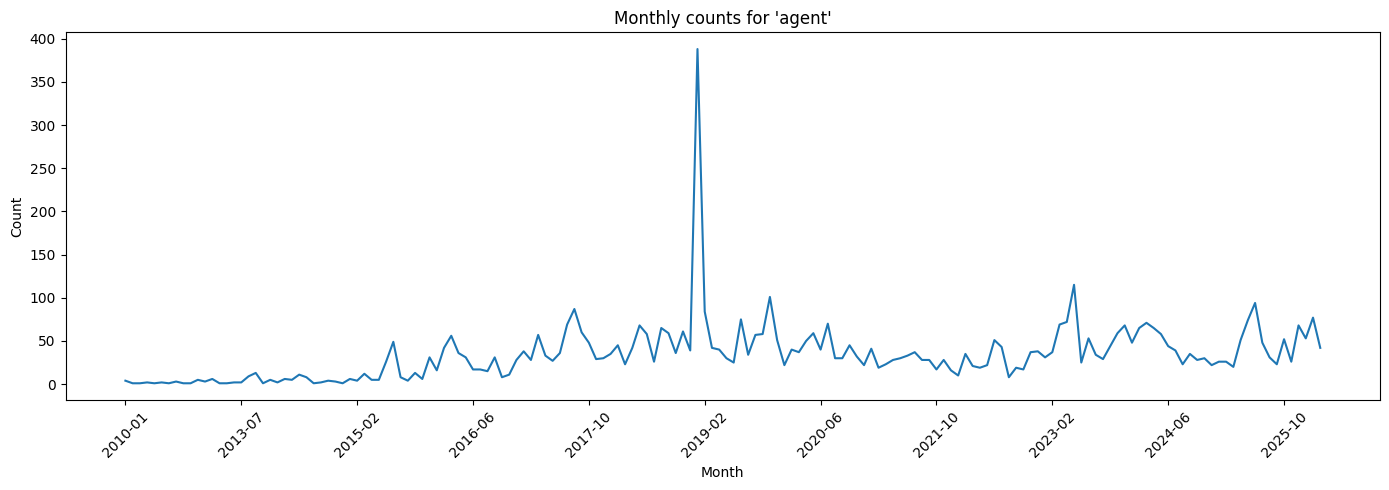

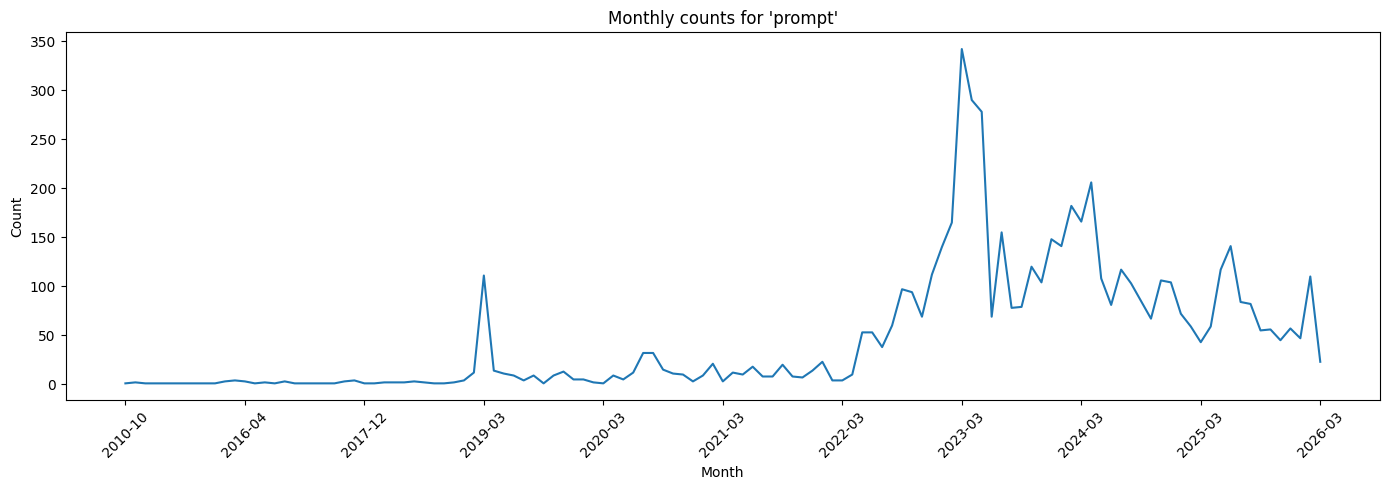

In [ ]:
plot_word_timeline(df, "model")
plot_word_timeline(df, "agent")
plot_word_timeline(df, "prompt")

In [ ]:
PROJECT_ROOT = "/content/drive/MyDrive/reddit_data/processed"

CONTEXT_DIR = os.path.join(PROJECT_ROOT, "contexts")
EMBED_DIR = os.path.join(PROJECT_ROOT, "embeddings")
CLUSTER_DIR = os.path.join(PROJECT_ROOT, "clusters")

os.makedirs(CONTEXT_DIR, exist_ok=True)
os.makedirs(EMBED_DIR, exist_ok=True)
os.makedirs(CLUSTER_DIR, exist_ok=True)

print("Directories ready")

Directories ready


In [ ]:
import os
import json
import re
import numpy as np
import pandas as pd
import hdbscan

from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [ ]:
# ---------- Basic config ----------
SUBREDDIT = "MachineLearning"
subreddit_dir = os.path.join(DATA_ROOT, SUBREDDIT)

target_words = [
    "prompt",
    "token",
    "alignment",
    "hallucination",
    "copilot",
    "agent",
    "model"
]

OLD_END = "2019-12"
NEW_START = "2023-01"

PER_MONTH_LIMIT = 200
WINDOW_SIZE = 40
MIN_CHARS = 40

HDBSCAN_MIN_CLUSTER_SIZE = 20
HDBSCAN_MIN_SAMPLES = 5

In [ ]:
def stream_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                yield json.loads(line)
            except:
                continue

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def get_month(created_utc):
    try:
        return pd.to_datetime(created_utc, unit="s").strftime("%Y-%m")
    except:
        return None

def extract_local_window(text, word, window_size=40):
    tokens = text.split()
    word = word.lower()

    positions = [i for i, tok in enumerate(tokens) if tok == word]
    if not positions:
        return []

    windows = []
    for i in positions:
        start = max(0, i - window_size)
        end = min(len(tokens), i + window_size + 1)
        windows.append(" ".join(tokens[start:end]))
    return windows

def extract_local_contexts_balanced(
    word,
    subreddit_dir,
    subreddit_name,
    per_month_limit=200,
    window_size=40,
    min_chars=40
):
    rows = []
    month_counts = {}
    files = sorted(os.listdir(subreddit_dir))

    for i, fname in enumerate(files, start=1):
        if not fname.endswith(".jsonl"):
            continue

        fpath = os.path.join(subreddit_dir, fname)
        print(f"[{word}] [{i}/{len(files)}] scanning {fname}")

        for comment in stream_jsonl(fpath):
            body = clean_text(comment.get("body", ""))
            if len(body) < min_chars:
                continue

            if f" {word} " not in f" {body} ":
                continue

            month = get_month(comment.get("created_utc"))
            if month is None:
                continue

            if month not in month_counts:
                month_counts[month] = 0

            if month_counts[month] >= per_month_limit:
                continue

            windows = extract_local_window(body, word, window_size=window_size)
            if not windows:
                continue

            for w in windows:
                if month_counts[month] >= per_month_limit:
                    break
                if len(w) < min_chars:
                    continue

                rows.append({
                    "word": word,
                    "month": month,
                    "subreddit": subreddit_name,
                    "text": w
                })
                month_counts[month] += 1

    df_out = pd.DataFrame(rows)
    if not df_out.empty:
        df_out = df_out.drop_duplicates(subset=["text"]).reset_index(drop=True)
    return df_out

def compute_drift_score(ctx_df, emb, old_end="2019-12", new_start="2023-01"):
    old_mask = ctx_df["month"] <= old_end
    new_mask = ctx_df["month"] >= new_start

    old_count = int(old_mask.sum())
    new_count = int(new_mask.sum())

    if old_count == 0 or new_count == 0:
        return None, old_count, new_count

    old_centroid = np.mean(emb[old_mask.values], axis=0)
    new_centroid = np.mean(emb[new_mask.values], axis=0)

    drift_score = 1 - cosine_similarity([old_centroid], [new_centroid])[0][0]
    return float(drift_score), old_count, new_count

def assign_period(month):
    if month <= OLD_END:
        return "old"
    elif month >= NEW_START:
        return "new"
    return "middle"

In [ ]:
embed_model = SentenceTransformer("all-mpnet-base-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
contexts_by_word = {}
embeddings_by_word = {}
drift_scores_by_word = {}
clustered_dfs_by_word = {}
cluster_period_tables_by_word = {}
cluster_period_props_by_word = {}
summary_rows = []

In [ ]:
for word in target_words:
    print(f"\n{'='*80}")
    print(f"PROCESSING WORD: {word}")
    print(f"{'='*80}")

    # 1) Extract contexts
    ctx = extract_local_contexts_balanced(
        word=word,
        subreddit_dir=subreddit_dir,
        subreddit_name=SUBREDDIT,
        per_month_limit=PER_MONTH_LIMIT,
        window_size=WINDOW_SIZE,
        min_chars=MIN_CHARS
    )

    contexts_by_word[word] = ctx

    if ctx.empty:
        print(f"[{word}] No contexts found.")
        summary_rows.append({
            "word": word,
            "n_contexts": 0,
            "min_month": None,
            "max_month": None,
            "old_count": 0,
            "new_count": 0,
            "drift_score": None,
            "n_clusters": 0,
            "noise_points": 0
        })
        continue

    print(f"[{word}] contexts shape: {ctx.shape}")
    print(f"[{word}] month range: {ctx['month'].min()} -> {ctx['month'].max()}")

    # SAVE CONTEXTS IMMEDIATELY
    context_path = os.path.join(CONTEXT_DIR, f"{word}_contexts.csv")
    ctx.to_csv(context_path, index=False)
    print(f"[{word}] Saved contexts: {context_path}")

    # 2) Embed
    texts = ctx["text"].tolist()
    emb = embed_model.encode(
        texts,
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True
    )
    embeddings_by_word[word] = emb
    print(f"[{word}] embeddings shape: {emb.shape}")

    # SAVE EMBEDDINGS IMMEDIATELY
    embed_path = os.path.join(EMBED_DIR, f"{word}_embeddings.npy")
    np.save(embed_path, emb)
    print(f"[{word}] Saved embeddings: {embed_path}")

    # 3) Drift
    drift_score, old_count, new_count = compute_drift_score(
        ctx, emb, old_end=OLD_END, new_start=NEW_START
    )
    drift_scores_by_word[word] = drift_score
    print(f"[{word}] old_count={old_count}, new_count={new_count}, drift={drift_score}")

    # 4) HDBSCAN
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
        min_samples=HDBSCAN_MIN_SAMPLES,
        metric="euclidean"
    )
    labels = clusterer.fit_predict(emb)

    ctx_clustered = ctx.copy()
    ctx_clustered["cluster"] = labels
    ctx_clustered["period"] = ctx_clustered["month"].apply(assign_period)

    clustered_dfs_by_word[word] = ctx_clustered

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_points = int(np.sum(labels == -1))

    print(f"[{word}] n_clusters={n_clusters}, noise_points={noise_points}")

    # SAVE CLUSTERS IMMEDIATELY
    cluster_path = os.path.join(CLUSTER_DIR, f"{word}_clusters.csv")
    ctx_clustered.to_csv(cluster_path, index=False)
    print(f"[{word}] Saved clusters: {cluster_path}")

    # 5) Cluster tables
    cluster_period_table = pd.crosstab(ctx_clustered["cluster"], ctx_clustered["period"])
    cluster_period_prop = pd.crosstab(
        ctx_clustered["cluster"],
        ctx_clustered["period"],
        normalize="columns"
    )

    cluster_period_tables_by_word[word] = cluster_period_table
    cluster_period_props_by_word[word] = cluster_period_prop

    # OPTIONAL: save cluster tables too
    cluster_table_path = os.path.join(CLUSTER_DIR, f"{word}_cluster_period_counts.csv")
    cluster_prop_path = os.path.join(CLUSTER_DIR, f"{word}_cluster_period_props.csv")

    cluster_period_table.to_csv(cluster_table_path)
    cluster_period_prop.to_csv(cluster_prop_path)

    print(f"[{word}] Saved cluster period counts: {cluster_table_path}")
    print(f"[{word}] Saved cluster period props: {cluster_prop_path}")

    # 6) Summary row
    summary_rows.append({
        "word": word,
        "n_contexts": len(ctx),
        "min_month": ctx["month"].min(),
        "max_month": ctx["month"].max(),
        "old_count": old_count,
        "new_count": new_count,
        "drift_score": drift_score,
        "n_clusters": n_clusters,
        "noise_points": noise_points
    })

    # OPTIONAL: save summary after each word too
    partial_summary_df = pd.DataFrame(summary_rows)
    partial_summary_path = os.path.join(PROJECT_ROOT, "partial_summary.csv")
    partial_summary_df.to_csv(partial_summary_path, index=False)
    print(f"[{word}] Updated partial summary: {partial_summary_path}")


PROCESSING WORD: prompt
[prompt] [1/18] scanning r_MachineLearning_comments_2009.jsonl
[prompt] [2/18] scanning r_MachineLearning_comments_2010.jsonl
[prompt] [3/18] scanning r_MachineLearning_comments_2011.jsonl
[prompt] [4/18] scanning r_MachineLearning_comments_2012.jsonl
[prompt] [5/18] scanning r_MachineLearning_comments_2013.jsonl
[prompt] [6/18] scanning r_MachineLearning_comments_2014.jsonl
[prompt] [7/18] scanning r_MachineLearning_comments_2015.jsonl
[prompt] [8/18] scanning r_MachineLearning_comments_2016.jsonl
[prompt] [9/18] scanning r_MachineLearning_comments_2017.jsonl
[prompt] [10/18] scanning r_MachineLearning_comments_2018.jsonl
[prompt] [11/18] scanning r_MachineLearning_comments_2019.jsonl
[prompt] [12/18] scanning r_MachineLearning_comments_2020.jsonl
[prompt] [13/18] scanning r_MachineLearning_comments_2021.jsonl
[prompt] [14/18] scanning r_MachineLearning_comments_2022.jsonl
[prompt] [15/18] scanning r_MachineLearning_comments_2023.jsonl
[prompt] [16/18] scannin

Batches:   0%|          | 0/119 [00:00<?, ?it/s]

[prompt] embeddings shape: (3783, 768)
[prompt] Saved embeddings: /content/drive/MyDrive/reddit_data/processed/embeddings/prompt_embeddings.npy
[prompt] old_count=107, new_count=3097, drift=0.13549280166625977
[prompt] n_clusters=2, noise_points=3603
[prompt] Saved clusters: /content/drive/MyDrive/reddit_data/processed/clusters/prompt_clusters.csv
[prompt] Saved cluster period counts: /content/drive/MyDrive/reddit_data/processed/clusters/prompt_cluster_period_counts.csv
[prompt] Saved cluster period props: /content/drive/MyDrive/reddit_data/processed/clusters/prompt_cluster_period_props.csv
[prompt] Updated partial summary: /content/drive/MyDrive/reddit_data/processed/partial_summary.csv

PROCESSING WORD: token
[token] [1/18] scanning r_MachineLearning_comments_2009.jsonl
[token] [2/18] scanning r_MachineLearning_comments_2010.jsonl
[token] [3/18] scanning r_MachineLearning_comments_2011.jsonl
[token] [4/18] scanning r_MachineLearning_comments_2012.jsonl
[token] [5/18] scanning r_Machi

Batches:   0%|          | 0/119 [00:00<?, ?it/s]

[token] embeddings shape: (3802, 768)
[token] Saved embeddings: /content/drive/MyDrive/reddit_data/processed/embeddings/token_embeddings.npy
[token] old_count=297, new_count=2948, drift=0.05879640579223633
[token] n_clusters=2, noise_points=3479
[token] Saved clusters: /content/drive/MyDrive/reddit_data/processed/clusters/token_clusters.csv
[token] Saved cluster period counts: /content/drive/MyDrive/reddit_data/processed/clusters/token_cluster_period_counts.csv
[token] Saved cluster period props: /content/drive/MyDrive/reddit_data/processed/clusters/token_cluster_period_props.csv
[token] Updated partial summary: /content/drive/MyDrive/reddit_data/processed/partial_summary.csv

PROCESSING WORD: alignment
[alignment] [1/18] scanning r_MachineLearning_comments_2009.jsonl
[alignment] [2/18] scanning r_MachineLearning_comments_2010.jsonl
[alignment] [3/18] scanning r_MachineLearning_comments_2011.jsonl
[alignment] [4/18] scanning r_MachineLearning_comments_2012.jsonl
[alignment] [5/18] scan

...

[copilot] embeddings shape: (402, 768)
[copilot] Saved embeddings: /content/drive/MyDrive/reddit_data/processed/embeddings/copilot_embeddings.npy
[copilot] old_count=0, new_count=310, drift=None
[copilot] n_clusters=0, noise_points=402
[copilot] Saved clusters: /content/drive/MyDrive/reddit_data/processed/clusters/copilot_clusters.csv
[copilot] Saved cluster period counts: /content/drive/MyDrive/reddit_data/processed/clusters/copilot_cluster_period_counts.csv
[copilot] Saved cluster period props: /content/drive/MyDrive/reddit_data/processed/clusters/copilot_cluster_period_props.csv
[copilot] Updated partial summary: /content/drive/MyDrive/reddit_data/processed/partial_summary.csv

PROCESSING WORD: agent
[agent] [1/18] scanning r_MachineLearning_comments_2009.jsonl
[agent] [2/18] scanning r_MachineLearning_comments_2010.jsonl
[agent] [3/18] scanning r_MachineLearning_comments_2011.jsonl
[agent] [4/18] scanning r_MachineLearning_comments_2012.jsonl
[agent] [5/18] scanning r_MachineLearni

Batches:   0%|          | 0/138 [00:00<?, ?it/s]

[agent] embeddings shape: (4389, 768)
[agent] Saved embeddings: /content/drive/MyDrive/reddit_data/processed/embeddings/agent_embeddings.npy
[agent] old_count=2051, new_count=1434, drift=0.08819526433944702
[agent] n_clusters=3, noise_points=4283
[agent] Saved clusters: /content/drive/MyDrive/reddit_data/processed/clusters/agent_clusters.csv
[agent] Saved cluster period counts: /content/drive/MyDrive/reddit_data/processed/clusters/agent_cluster_period_counts.csv
[agent] Saved cluster period props: /content/drive/MyDrive/reddit_data/processed/clusters/agent_cluster_period_props.csv
[agent] Updated partial summary: /content/drive/MyDrive/reddit_data/processed/partial_summary.csv

PROCESSING WORD: model
[model] [1/18] scanning r_MachineLearning_comments_2009.jsonl
[model] [2/18] scanning r_MachineLearning_comments_2010.jsonl
[model] [3/18] scanning r_MachineLearning_comments_2011.jsonl
[model] [4/18] scanning r_MachineLearning_comments_2012.jsonl
[model] [5/18] scanning r_MachineLearning_

Batches:   0%|          | 0/898 [00:00<?, ?it/s]

[model] embeddings shape: (28724, 768)
[model] Saved embeddings: /content/drive/MyDrive/reddit_data/processed/embeddings/model_embeddings.npy
[model] old_count=14281, new_count=7441, drift=0.03809952735900879
[model] n_clusters=2, noise_points=19570
[model] Saved clusters: /content/drive/MyDrive/reddit_data/processed/clusters/model_clusters.csv
[model] Saved cluster period counts: /content/drive/MyDrive/reddit_data/processed/clusters/model_cluster_period_counts.csv
[model] Saved cluster period props: /content/drive/MyDrive/reddit_data/processed/clusters/model_cluster_period_props.csv
[model] Updated partial summary: /content/drive/MyDrive/reddit_data/processed/partial_summary.csv


In [ ]:
def inspect_word_clusters(word, n_samples=8):
    if word not in clustered_dfs_by_word:
        print(f"No clustered data found for: {word}")
        return

    dfw = clustered_dfs_by_word[word]

    print(f"\nWORD: {word}")
    print("Drift score:", drift_scores_by_word.get(word))
    print("\nCluster counts:")
    print(dfw["cluster"].value_counts().sort_index())

    print("\nCluster by period (raw counts):")
    print(cluster_period_tables_by_word[word])

    print("\nCluster by period (proportions):")
    print(cluster_period_props_by_word[word])

    for c in sorted(dfw["cluster"].unique()):
        if c == -1:
            continue
        print(f"\n===== {word.upper()} CLUSTER {c} =====")
        sample = dfw[dfw["cluster"] == c][["month", "text"]].sample(
            min(n_samples, (dfw["cluster"] == c).sum()),
            random_state=42
        )
        display(sample)

In [ ]:
inspect_word_clusters("prompt")
inspect_word_clusters("agent")
inspect_word_clusters("model")


WORD: prompt
Drift score: 0.13549280166625977

Cluster counts:
cluster
-1    3603
 0     160
 1      20
Name: count, dtype: int64

Cluster by period (raw counts):
period   middle   new  old
cluster                   
-1          558  2938  107
 0           14   146    0
 1            7    13    0

Cluster by period (proportions):
period     middle       new  old
cluster                         
-1       0.963731  0.948660  1.0
 0       0.024180  0.047142  0.0
 1       0.012090  0.004198  0.0

===== PROMPT CLUSTER 0 =====


,month,text
2772,2024-09,model now learns well and has good responses. ...
2792,2024-09,the fundamental basis of prompt engineering is...
3357,2025-07,that's been suggested as best practice but imh...
1591,2023-07,"a prompt usually includes context, examples, i..."
2480,2024-05,sure. instead of using a single prompt with mu...
1467,2023-06,it's somewhat task dependant but i think the e...
2652,2024-07,seems intuitive but good to confirm i guess. l...
1585,2023-07,"if anything, prompt engineers become the users..."



===== PROMPT CLUSTER 1 =====


,month,text
129,2020-07,"gpt-3 is not being trained on prompt data, as ..."
2977,2024-12,for the newer tools they have added. there was...
2427,2024-04,it's often helpful to provide a sample prompt ...
144,2020-07,unfortunately gpt-3 isn't doing anything reall...
731,2023-01,think of chatgpt as a multi-task meta-learner ...
339,2022-05,performs better at maths in a specific dataset...
1058,2023-03,to be told to do it. i hope the plugin functio...
179,2020-10,the best way to find out is to experiment. in ...



WORD: agent
Drift score: 0.08819526433944702

Cluster counts:
cluster
-1    4283
 0      21
 1      48
 2      37
Name: count, dtype: int64

Cluster by period (raw counts):
period   middle   new   old
cluster                    
-1          875  1426  1982
 0            2     0    19
 1           17     7    24
 2           10     1    26

Cluster by period (proportions):
period     middle       new       old
cluster                              
-1       0.967920  0.994421  0.966358
 0       0.002212  0.000000  0.009264
 1       0.018805  0.004881  0.011702
 2       0.011062  0.000697  0.012677

===== AGENT CLUSTER 0 =====


...

,month,text
1127,2018-06,head to head against another agent hence teach...
1123,2018-06,"indeed, playing against human opponents can te..."
575,2017-03,"> ""an agent should be capable of learning new ..."
2278,2020-07,courville]( [philip bachman]( > abstract: whil...
2907,2022-11,the more viable option of transferring the exi...
2050,2019-12,can represent knowledge about the environment ...
602,2017-04,extremely poor. this may be acceptable for a s...
2131,2020-03,test general competency of rl algorithms. prev...



WORD: model
Drift score: 0.03809952735900879

Cluster counts:
cluster
-1    19570
 0       31
 1     9123
Name: count, dtype: int64

Cluster by period (raw counts):
period   middle   new   old
cluster                    
-1         4646  5151  9773
 0            2     3    26
 1         2354  2287  4482

Cluster by period (proportions):
period     middle       new       old
cluster                              
-1       0.663525  0.692246  0.684336
 0       0.000286  0.000403  0.001821
 1       0.336190  0.307351  0.313844

===== MODEL CLUSTER 0 =====


,month,text
18492,2021-10,i've been working on a model but i feel like i...
3948,2015-07,it doesn't sound to me like you need a machine...
13381,2019-08,"hi reddit, together with colleagues from epfl ..."
5171,2016-02,"tonight's matches and your predictions, i thin..."
2056,2014-07,to solve this with machine learning or statist...
2407,2014-11,you are much better off building a probabilist...
23385,2023-11,lol ur telling me u have an accurate model tha...
13382,2019-08,of players & teams change over time in a more ...



===== MODEL CLUSTER 1 =====


,month,text
10223,2018-04,this is helpful for sharing a model **and** pr...
14192,2019-12,further investigation: the claims seem to be: ...
10336,2018-04,">unfortunately, we could not train our models ..."
10866,2018-07,powerful model with lots of data and lots of c...
26034,2025-01,\>can we feed these model weights into gpt and...
8248,2017-05,"this way, by doing things like differentiating..."
1816,2014-05,"experise. most data is unlabeled, and getting ..."
3368,2015-04,tutorial. i would though like to use deep lear...


In [ ]:
def show_old_new_samples(word, n=5):
    if word not in contexts_by_word:
        print(f"No contexts found for: {word}")
        return

    ctx = contexts_by_word[word]
    old_mask = ctx["month"] <= OLD_END
    new_mask = ctx["month"] >= NEW_START

    print(f"\n===== {word.upper()} OLD SAMPLES =====")
    if int(old_mask.sum()) > 0:
        display(ctx[old_mask][["month", "text"]].sample(min(n, int(old_mask.sum())), random_state=42))
    else:
        print("No old samples")

    print(f"\n===== {word.upper()} NEW SAMPLES =====")
    if int(new_mask.sum()) > 0:
        display(ctx[new_mask][["month", "text"]].sample(min(n, int(new_mask.sum())), random_state=42))
    else:
        print("No new samples")

In [ ]:
show_old_new_samples("hallucination")
show_old_new_samples("alignment")


===== HALLUCINATION OLD SAMPLES =====


,month,text
0,2013-07,'l' for example. specifically for digit recogn...
1,2016-01,i'd love to see a comparison against this pca-...
5,2019-03,"after you grow old and die, you wake up 10 mil..."
2,2016-04,lot of dropout with thc to be honest though. i...
4,2018-04,be hilariously awful if it became widespread a...



===== HALLUCINATION NEW SAMPLES =====


,month,text
43,2023-03,the problem; self-supervised learning. it lear...
301,2026-01,state isn't just a random point in space. it i...
177,2024-05,genuine question as this is a knowledge gap on...
246,2025-06,"aren't ""true"" probabilities, because the optim..."
261,2025-08,interesting thought on ldv. it makes sense tha...



===== ALIGNMENT OLD SAMPLES =====


,month,text
281,2019-09,the goal is to have good performance on a targ...
265,2019-09,this list is much appreciated. do any of these...
164,2018-01,i've found this type of attention to perform w...
9,2014-03,the way blast and other alignment algorithms w...
77,2016-01,"first ten inputs, the second to the next 5 and..."



===== ALIGNMENT NEW SAMPLES =====


,month,text
812,2023-09,"few of my top recommendations: ""**artificial i..."
1037,2025-06,"the specific area you're talking about, but i ..."
783,2023-07,to dangerous to ever attempt. the only ones wh...
862,2024-01,going to the legs and the bowel/bladder. now p...
844,2023-12,> utterance level alignment is there because t...


Get appearance and breakout for prompt

In [ ]:
word = "prompt"

appearance_month, appearance_window = find_appearance_month(
    df, word, min_count=20, sustain_months=2
)

breakout_month, breakout_info = find_breakout_month(
    df,
    word,
    appearance_month,
    min_count=30,
    growth_ratio=3.0,
    lookback=3
)

print("Appearance:", appearance_month)
print("Breakout:", breakout_month)
print("Breakout info:", breakout_info)

Appearance: 2020-07
Breakout: 2020-07
Breakout info: {'month': '2020-07', 'count': 32, 'prev_avg': np.float64(8.666666666666666), 'growth_ratio': np.float64(3.6923076923076925)}


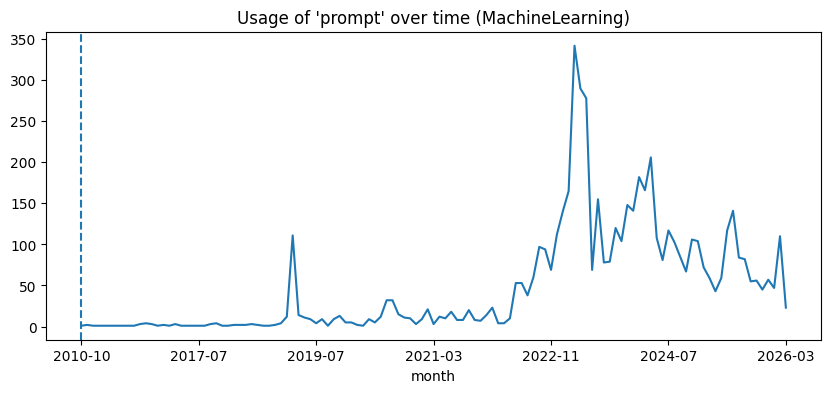

In [ ]:
import matplotlib.pyplot as plt

w = "prompt"
series = df[df["word"] == w].set_index("month")["count"]

plt.figure(figsize=(10,4))
series.plot()
plt.axvline("2020-07", linestyle="--")
plt.title("Usage of 'prompt' over time (MachineLearning)")
plt.show()

In [ ]:
def analyze_word_live(
    word,
    df_counts,
    subreddit_dir,
    subreddit_name,
    per_month_limit=200,
    window_size=40,
    min_chars=40,
    old_end="2019-12",
    new_start="2023-01",
    min_cluster_size=20,
    min_samples=5
):
    word = word.lower().strip()

    # 1) appearance / breakout
    appearance_month, _ = find_appearance_month(
        df_counts, word, min_count=20, sustain_months=2
    )

    breakout_month, breakout_info = find_breakout_month(
        df_counts, word, appearance_month,
        min_count=30, growth_ratio=3.0, lookback=3
    )

    # 2) contexts
    ctx = extract_local_contexts_balanced(
        word=word,
        subreddit_dir=subreddit_dir,
        subreddit_name=subreddit_name,
        per_month_limit=per_month_limit,
        window_size=window_size,
        min_chars=min_chars
    )

    if ctx.empty:
        return {
            "word": word,
            "status": "no_contexts_found",
            "appearance": appearance_month,
            "breakout": breakout_month,
            "breakout_info": breakout_info
        }

    # 3) embeddings
    texts = ctx["text"].tolist()
    emb = embed_model.encode(
        texts,
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True
    )

    # 4) drift
    drift_score, old_count, new_count = compute_drift_score(
        ctx, emb, old_end=old_end, new_start=new_start
    )

    # 5) evidence check
    if old_count < 20 or new_count < 20:
        return {
            "word": word,
            "status": "insufficient_evidence",
            "appearance": appearance_month,
            "breakout": breakout_month,
            "breakout_info": breakout_info,
            "n_contexts": len(ctx),
            "old_count": old_count,
            "new_count": new_count,
            "drift_score": drift_score,
            "ctx": ctx,
            "emb": emb
        }

    # 6) clustering
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric="euclidean"
    )
    labels = clusterer.fit_predict(emb)

    ctx_clustered = ctx.copy()
    ctx_clustered["cluster"] = labels
    ctx_clustered["period"] = ctx_clustered["month"].apply(assign_period)

    cluster_period_counts = pd.crosstab(ctx_clustered["cluster"], ctx_clustered["period"])
    cluster_period_props = pd.crosstab(
        ctx_clustered["cluster"],
        ctx_clustered["period"],
        normalize="columns"
    )

    return {
        "word": word,
        "status": "ok",
        "appearance": appearance_month,
        "breakout": breakout_month,
        "breakout_info": breakout_info,
        "n_contexts": len(ctx),
        "old_count": old_count,
        "new_count": new_count,
        "drift_score": drift_score,
        "ctx": ctx,
        "emb": emb,
        "clustered_df": ctx_clustered,
        "cluster_period_counts": cluster_period_counts,
        "cluster_period_props": cluster_period_props
    }

In [ ]:
def save_analysis_result(result):
    word = result["word"]

    if "ctx" in result and result["ctx"] is not None:
        result["ctx"].to_csv(
            os.path.join(CONTEXT_DIR, f"{word}_contexts.csv"),
            index=False
        )

    if "emb" in result and result["emb"] is not None:
        np.save(
            os.path.join(EMBED_DIR, f"{word}_embeddings.npy"),
            result["emb"]
        )

    if result.get("status") == "ok":
        result["clustered_df"].to_csv(
            os.path.join(CLUSTER_DIR, f"{word}_clusters.csv"),
            index=False
        )
        result["cluster_period_counts"].to_csv(
            os.path.join(CLUSTER_DIR, f"{word}_cluster_period_counts.csv")
        )
        result["cluster_period_props"].to_csv(
            os.path.join(CLUSTER_DIR, f"{word}_cluster_period_props.csv")
        )

In [ ]:
def analyze_word_live(
    word,
    df_counts,
    subreddit_dir,
    subreddit_name,
    per_month_limit=200,
    window_size=40,
    min_chars=40,
    old_end="2019-12",
    new_start="2023-01",
    min_cluster_size=20,
    min_samples=5
):

    word = word.lower().strip()

    # appearance
    appearance_month, _ = find_appearance_month(
        df_counts, word, min_count=20, sustain_months=2
    )

    # breakout
    breakout_month, breakout_info = find_breakout_month(
        df_counts, word, appearance_month,
        min_count=30, growth_ratio=3.0, lookback=3
    )

    # contexts
    ctx = extract_local_contexts_balanced(
        word=word,
        subreddit_dir=subreddit_dir,
        subreddit_name=subreddit_name,
        per_month_limit=per_month_limit,
        window_size=window_size,
        min_chars=min_chars
    )

    if ctx.empty:
        return {
            "word": word,
            "status": "no_contexts_found",
            "appearance": appearance_month,
            "breakout": breakout_month
        }

    # embeddings
    texts = ctx["text"].tolist()

    emb = embed_model.encode(
        texts,
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True
    )

    # drift
    drift_score, old_count, new_count = compute_drift_score(
        ctx,
        emb,
        old_end=old_end,
        new_start=new_start
    )

    # clustering
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric="euclidean"
    )

    labels = clusterer.fit_predict(emb)

    ctx_clustered = ctx.copy()
    ctx_clustered["cluster"] = labels
    ctx_clustered["period"] = ctx_clustered["month"].apply(assign_period)

    cluster_period_counts = pd.crosstab(
        ctx_clustered["cluster"],
        ctx_clustered["period"]
    )

    cluster_period_props = pd.crosstab(
        ctx_clustered["cluster"],
        ctx_clustered["period"],
        normalize="columns"
    )

    return {
        "word": word,
        "status": "ok",
        "appearance": appearance_month,
        "breakout": breakout_month,
        "breakout_info": breakout_info,
        "drift_score": drift_score,
        "old_count": old_count,
        "new_count": new_count,
        "ctx": ctx,
        "emb": emb,
        "clustered_df": ctx_clustered,
        "cluster_period_counts": cluster_period_counts,
        "cluster_period_props": cluster_period_props
    }

In [ ]:
def analyze_word(word):
    word = word.lower().strip()

    context_path = os.path.join(CONTEXT_DIR, f"{word}_contexts.csv")
    embed_path = os.path.join(EMBED_DIR, f"{word}_embeddings.npy")
    cluster_path = os.path.join(CLUSTER_DIR, f"{word}_clusters.csv")
    cluster_counts_path = os.path.join(CLUSTER_DIR, f"{word}_cluster_period_counts.csv")
    cluster_props_path = os.path.join(CLUSTER_DIR, f"{word}_cluster_period_props.csv")

    already_processed = (
        os.path.exists(context_path) and
        os.path.exists(embed_path)
    )

    if already_processed:
        print(f"Loading saved analysis for '{word}'")
        return query_word(word)

    print(f"No saved analysis found for '{word}'. Running live analysis...")

    result = analyze_word_live(
        word=word,
        df_counts=df,
        subreddit_dir=subreddit_dir,
        subreddit_name=SUBREDDIT,
        per_month_limit=200,
        window_size=40,
        min_chars=40
    )

    if result.get("status") in ["ok", "insufficient_evidence"]:
        save_analysis_result(result)

    return result

In [ ]:
def print_analysis_result(result):
    if result is None:
        print("No result")
        return

    print(f"Word: {result['word']}")
    print(f"Status: {result.get('status', 'loaded')}")
    print(f"Appearance: {result.get('appearance')}")
    print(f"Breakout: {result.get('breakout')}")
    print(f"Breakout info: {result.get('breakout_info')}")
    print(f"Drift score: {result.get('drift_score')}")
    print(f"Contexts: {result.get('n_contexts', len(result['ctx']) if 'ctx' in result else None)}")
    print(f"Old contexts: {result.get('old_count')}")
    print(f"New contexts: {result.get('new_count')}")

In [ ]:
result = analyze_word("diffusion")
print_analysis_result(result)

No saved analysis found for 'diffusion'. Running live analysis...
[diffusion] [1/18] scanning r_MachineLearning_comments_2009.jsonl
[diffusion] [2/18] scanning r_MachineLearning_comments_2010.jsonl
[diffusion] [3/18] scanning r_MachineLearning_comments_2011.jsonl
[diffusion] [4/18] scanning r_MachineLearning_comments_2012.jsonl
[diffusion] [5/18] scanning r_MachineLearning_comments_2013.jsonl
[diffusion] [6/18] scanning r_MachineLearning_comments_2014.jsonl
[diffusion] [7/18] scanning r_MachineLearning_comments_2015.jsonl
[diffusion] [8/18] scanning r_MachineLearning_comments_2016.jsonl
[diffusion] [9/18] scanning r_MachineLearning_comments_2017.jsonl
[diffusion] [10/18] scanning r_MachineLearning_comments_2018.jsonl
[diffusion] [11/18] scanning r_MachineLearning_comments_2019.jsonl
[diffusion] [12/18] scanning r_MachineLearning_comments_2020.jsonl
[diffusion] [13/18] scanning r_MachineLearning_comments_2021.jsonl
[diffusion] [14/18] scanning r_MachineLearning_comments_2022.jsonl
[diff

Batches:   0%|          | 0/117 [00:00<?, ?it/s]

Word: diffusion
Status: ok
Appearance: 2022-03
Breakout: 2022-04
Breakout info: {'month': '2022-04', 'count': 64, 'prev_avg': np.float64(18.666666666666668), 'growth_ratio': np.float64(3.4285714285714284)}
Drift score: 0.12156188488006592
Contexts: 3724
Old contexts: 64
New contexts: 2784


In [ ]:
save_analysis_result(result)
print("Saved live analysis for diffusion")

Saved live analysis for diffusion


In [ ]:
def query_word(word):
    word = word.lower().strip()

    context_path = os.path.join(CONTEXT_DIR, f"{word}_contexts.csv")
    embed_path = os.path.join(EMBED_DIR, f"{word}_embeddings.npy")
    cluster_path = os.path.join(CLUSTER_DIR, f"{word}_clusters.csv")
    cluster_counts_path = os.path.join(CLUSTER_DIR, f"{word}_cluster_period_counts.csv")
    cluster_props_path = os.path.join(CLUSTER_DIR, f"{word}_cluster_period_props.csv")

    if not os.path.exists(context_path):
        print(f"No precomputed contexts found for '{word}'")
        return None

    ctx = pd.read_csv(context_path)

    emb = None
    if os.path.exists(embed_path):
        emb = np.load(embed_path)

    clustered_df = None
    if os.path.exists(cluster_path):
        clustered_df = pd.read_csv(cluster_path)

    cluster_period_counts = None
    if os.path.exists(cluster_counts_path):
        cluster_period_counts = pd.read_csv(cluster_counts_path, index_col=0)

    cluster_period_props = None
    if os.path.exists(cluster_props_path):
        cluster_period_props = pd.read_csv(cluster_props_path, index_col=0)

    appearance_month, _ = find_appearance_month(
        df, word, min_count=20, sustain_months=2
    )

    breakout_month, breakout_info = find_breakout_month(
        df, word, appearance_month, min_count=30, growth_ratio=3.0, lookback=3
    )

    drift_score = None
    old_count, new_count = 0, 0
    if emb is not None:
        drift_score, old_count, new_count = compute_drift_score(
            ctx, emb, old_end=OLD_END, new_start=NEW_START
        )

    return {
        "word": word,
        "status": "loaded",
        "appearance": appearance_month,
        "breakout": breakout_month,
        "breakout_info": breakout_info,
        "drift_score": drift_score,
        "old_count": old_count,
        "new_count": new_count,
        "ctx": ctx,
        "emb": emb,
        "clustered_df": clustered_df,
        "cluster_period_counts": cluster_period_counts,
        "cluster_period_props": cluster_period_props
    }

In [ ]:
def show_result_samples(result, n=5):
    if result is None or "ctx" not in result or result["ctx"] is None:
        print("No contexts available")
        return

    ctx = result["ctx"]
    old_mask = ctx["month"] <= OLD_END
    new_mask = ctx["month"] >= NEW_START

    print("\nOLD SAMPLES")
    if int(old_mask.sum()) > 0:
        display(ctx[old_mask][["month", "text"]].sample(min(n, int(old_mask.sum())), random_state=42))
    else:
        print("No old samples")

    print("\nNEW SAMPLES")
    if int(new_mask.sum()) > 0:
        display(ctx[new_mask][["month", "text"]].sample(min(n, int(new_mask.sum())), random_state=42))
    else:
        print("No new samples")

In [ ]:
def show_result_clusters(result, n=5):
    if result is None or result.get("clustered_df") is None:
        print("No usable cluster result")
        return

    clustered_df = result["clustered_df"]

    print("Cluster counts:")
    print(clustered_df["cluster"].value_counts().sort_index())

    if result.get("cluster_period_counts") is not None:
        print("\nCluster by period (raw counts):")
        display(result["cluster_period_counts"])

    if result.get("cluster_period_props") is not None:
        print("\nCluster by period (proportions):")
        display(result["cluster_period_props"])

    for c in sorted(clustered_df["cluster"].unique()):
        if c == -1:
            continue
        print(f"\n===== CLUSTER {c} =====")
        display(
            clustered_df[clustered_df["cluster"] == c][["month", "text"]]
            .sample(min(n, (clustered_df["cluster"] == c).sum()), random_state=42)
        )

In [ ]:
def print_analysis_result(result):
    if result is None:
        print("No result")
        return

    print(f"Word: {result['word']}")
    print(f"Status: {result.get('status')}")
    print(f"Appearance: {result.get('appearance')}")
    print(f"Breakout: {result.get('breakout')}")
    print(f"Breakout info: {result.get('breakout_info')}")
    print(f"Drift score: {result.get('drift_score')}")
    print(f"Old contexts: {result.get('old_count')}")
    print(f"New contexts: {result.get('new_count')}")

In [ ]:
result = analyze_word("diffusion")

Loading saved analysis for 'diffusion'


In [ ]:
show_result_samples(result, n=5)
show_result_clusters(result, n=5)


OLD SAMPLES


,month,text
52,2019-03,1. just because the prior is gaussian and the ...
58,2019-06,"maps, laplacian eigenmaps, and commute time em..."
0,2014-03,distribution]( a freely diffusing angle on a c...
44,2018-11,fact i would think the only parameter able to ...
5,2015-05,interesting. what is the reasoning behind the ...



NEW SAMPLES


,month,text
1447,2023-04,"hello everyone, how are you able to compute th..."
3208,2025-04,nice work! i don’t know too much about this ar...
3289,2025-05,i'm wondering is this a continuous diffusion m...
2728,2024-08,"(neural odes). that being said, flow matching ..."
1889,2023-11,or travel to the right point in the past and i...


Cluster counts:
cluster
-1    3478
 0      93
 1     110
 2      43
Name: count, dtype: int64

Cluster by period (raw counts):


...

,month,text
689,2022-10,my opinion the main problem with gans is how u...
213,2022-04,hi guys! we've released the code & colab demo ...
1083,2023-01,progress) \- it's simpler (which leads to prog...
1931,2023-11,"diffusion runs the model a bunch of times, rem..."
107,2021-05,title:diffusion models beat gans on image synt...



===== CLUSTER 1 =====


,month,text
2607,2024-05,amazing repository. thank you for the reply. i...
427,2022-08,hmm. i’ve been seeing a lot of “stable diffusi...
285,2022-05,>the important part about diffusion models is ...
2822,2024-09,> and in fact you do not need noise in a diffu...
2099,2024-01,of regularizing the model and the training pro...



===== CLUSTER 2 =====


,month,text
3031,2024-12,work. you can do diffusion right in the pixel ...
2389,2024-03,"lost case, in my opinion, just an shinier new ..."
2390,2024-03,as far as i understand the latest stable diffu...
3030,2024-12,diffusion doesn't even need a vae at all to wo...
3028,2024-12,diffusion doesn't even need a vae at all to wo...


In [ ]:
result = analyze_word("transformer")
print_analysis_result(result)

No saved analysis found for 'transformer'. Running live analysis...
[transformer] [1/18] scanning r_MachineLearning_comments_2009.jsonl
[transformer] [2/18] scanning r_MachineLearning_comments_2010.jsonl
[transformer] [3/18] scanning r_MachineLearning_comments_2011.jsonl
[transformer] [4/18] scanning r_MachineLearning_comments_2012.jsonl
[transformer] [5/18] scanning r_MachineLearning_comments_2013.jsonl
[transformer] [6/18] scanning r_MachineLearning_comments_2014.jsonl
[transformer] [7/18] scanning r_MachineLearning_comments_2015.jsonl
[transformer] [8/18] scanning r_MachineLearning_comments_2016.jsonl
[transformer] [9/18] scanning r_MachineLearning_comments_2017.jsonl
[transformer] [10/18] scanning r_MachineLearning_comments_2018.jsonl
[transformer] [11/18] scanning r_MachineLearning_comments_2019.jsonl
[transformer] [12/18] scanning r_MachineLearning_comments_2020.jsonl
[transformer] [13/18] scanning r_MachineLearning_comments_2021.jsonl
[transformer] [14/18] scanning r_MachineLear

Batches:   0%|          | 0/177 [00:00<?, ?it/s]

Word: transformer
Status: ok
Appearance: 2018-07
Breakout: 2018-12
Breakout info: {'month': '2018-12', 'count': 53, 'prev_avg': np.float64(17.333333333333332), 'growth_ratio': np.float64(3.057692307692308)}
Drift score: 0.027355849742889404
Old contexts: 605
New contexts: 2997


In [ ]:
result = analyze_word("transformer")

Loading saved analysis for 'transformer'


In [ ]:
show_result_samples(result, n=5)
show_result_clusters(result, n=5)


OLD SAMPLES


,month,text
412,2019-06,"hey man, absolutely love your work! i always r..."
289,2019-02,"head, using a relu activation and highly negat..."
76,2018-04,in the tf graph i have a py_func node that loa...
78,2018-04,"where the cats cover 90% of the image, then th..."
182,2018-09,"yeah. actually, transformer being sota in wiki..."



NEW SAMPLES


,month,text
4013,2024-02,"dataset and learning rate. clearly, models hav..."
3570,2023-11,one approach used on transformer models is to ...
2782,2023-02,example any military creating an agi will forg...
5575,2026-01,"i have not interviewed there specifically, but..."
2689,2023-01,oh ok. thank you for taking the time to explai...


Cluster counts:
cluster
-1    5519
 0      80
 1      36
Name: count, dtype: int64

Cluster by period (raw counts):


...

,middle,new,old
cluster,,,
-1,0.978849,0.985652,0.950413
0,0.014757,0.013347,0.016529
1,0.006394,0.001001,0.033058



===== CLUSTER 0 =====


,month,text
1944,2021-12,> there's probably no reason an lstm architect...
112,2018-06,hello r/machinelearning. author here. i spent ...
1260,2021-01,i still don't fully understand transformer arc...
1945,2021-12,their point is still valid though. the benefit...
1079,2020-10,"first, let me say that i understand your frust..."



===== CLUSTER 1 =====


,month,text
4944,2024-12,improves accuracy by more than 50 points over ...
362,2019-05,li]( [alexander j. smola]( > abstract: the tra...
1773,2021-09,title:primer: searching for efficient transfor...
1880,2021-11,title:pruning attention heads of transformer m...
416,2019-07,title:augmenting self-attention with persisten...


In [ ]:
result = analyze_word("classification")
print_analysis_result(result)

No saved analysis found for 'classification'. Running live analysis...
[classification] [1/18] scanning r_MachineLearning_comments_2009.jsonl
[classification] [2/18] scanning r_MachineLearning_comments_2010.jsonl
[classification] [3/18] scanning r_MachineLearning_comments_2011.jsonl
[classification] [4/18] scanning r_MachineLearning_comments_2012.jsonl
[classification] [5/18] scanning r_MachineLearning_comments_2013.jsonl
[classification] [6/18] scanning r_MachineLearning_comments_2014.jsonl
[classification] [7/18] scanning r_MachineLearning_comments_2015.jsonl
[classification] [8/18] scanning r_MachineLearning_comments_2016.jsonl
[classification] [9/18] scanning r_MachineLearning_comments_2017.jsonl
[classification] [10/18] scanning r_MachineLearning_comments_2018.jsonl
[classification] [11/18] scanning r_MachineLearning_comments_2019.jsonl
[classification] [12/18] scanning r_MachineLearning_comments_2020.jsonl
[classification] [13/18] scanning r_MachineLearning_comments_2021.jsonl
[c

Batches:   0%|          | 0/274 [00:00<?, ?it/s]

Word: classification
Status: ok
Appearance: 2013-01
Breakout: None
Breakout info: None
Drift score: 0.03070700168609619
Old contexts: 4305
New contexts: 1897
